# Calibration of modular detectors using Debye-Scherrer rings

Developed initally by Jonathan P. Wright, Carlotta Giacobbe and Eleanor Lawrence Bright from ESRF-ID11 in https://doi.org/10.3390/cryst12020255

Images can be obtained from: https://www.silx.org/pub/pyFAI/detector_calibration/Eiger2-ID11/CeO2_Spatial_distortion_apr2021.tar.gz

In [1]:
%matplotlib inline

In [53]:
import glob
import os
import time
import inspect
from math import sin, cos, pi
from matplotlib.pyplot import subplots
from IPython.display import Markdown
import numpy
import fabio
from scipy import ndimage, optimize
import pyFAI
from pyFAI.gui import jupyter
from pyFAI.control_points import ControlPoints
from pyFAI.goniometer import SingleGeometry
from pyFAI.io.ponifile import PoniFile
from pyFAI.ext import _geometry
from pyFAI.third_party.classproperties import classproperty
from pyFAI.detectors.multi_module import ModuleParam, PoniParam, SingleModule, MultiModule, MultiModuleRefinement
from pyFAI.utils.grid import Kabsch
print(f"Using pyFAI version {pyFAI.version}")
start_time = time.perf_counter()

Using pyFAI version 2026.9.0-dev0


In [49]:
ponis = glob.glob("*.poni")
ponis.sort()
cpf = glob.glob("*.npt")
cpf.sort()

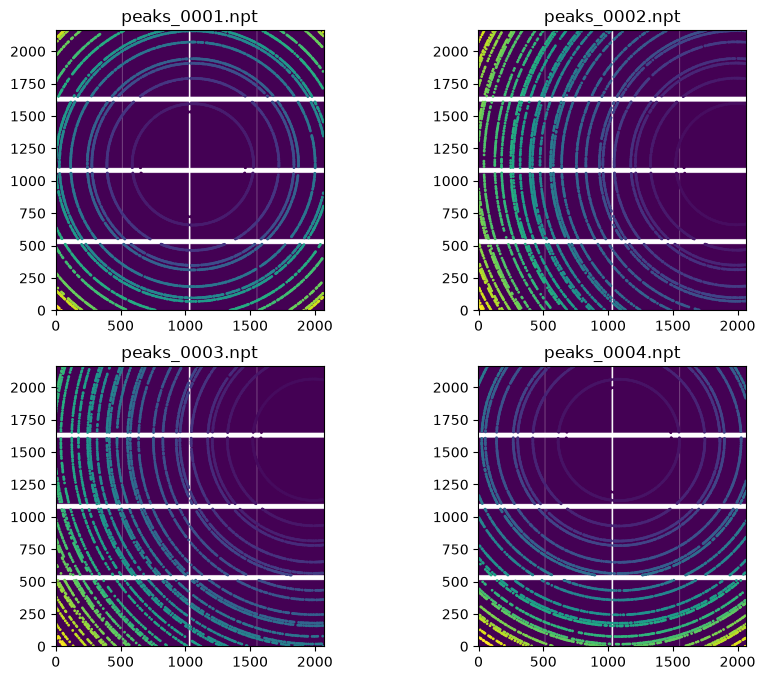

In [48]:
fig, ax = subplots(2,2, figsize=(10,8))
shape = pyFAI.load(ponis[0]).detector.shape
for i, c in enumerate(cpf):
    img = numpy.zeros(detector.shape)
    img[detector.mask>0] = numpy.nan
    cp = ControlPoints(c)
    y, x, n = numpy.array(cp.getList()).T
    ax[i//2, i%2].imshow(img, origin="lower")
    ax[i//2, i%2].set_title(c)
    ax[i//2, i%2].scatter(x, y, 1, c=n)

## The Eiger 4M is built of 4x4 modules:

MultiModule with 16 modules:
   1: Module centered at (256.0, 256.5).
   2: Module centered at (256.0, 771.5).
   3: Module centered at (256.0, 1296.5).
   4: Module centered at (256.0, 1811.5).
   5: Module centered at (806.0, 256.5).
   6: Module centered at (806.0, 771.5).
   7: Module centered at (806.0, 1296.5).
   8: Module centered at (806.0, 1811.5).
   9: Module centered at (1356.0, 256.5).
  10: Module centered at (1356.0, 771.5).
  11: Module centered at (1356.0, 1296.5).
  12: Module centered at (1356.0, 1811.5).
  13: Module centered at (1906.0, 256.5).
  14: Module centered at (1906.0, 771.5).
  15: Module centered at (1906.0, 1296.5).
  16: Module centered at (1906.0, 1811.5).


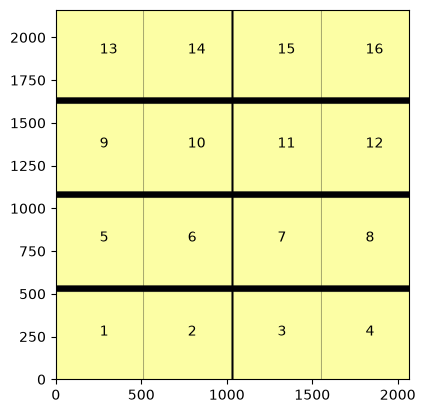

In [3]:
# This is the detector used on ID11
detector = pyFAI.detector_factory("Eiger2_CdTe_4M")
mm = MultiModuleRefinement.from_detector(detector)
ax = jupyter.display(1-detector.mask)
for i,j  in mm.modules.items():
    ax.annotate(str(i), [float(k.ravel()[0]) for k in j.center[-1::-1]])
print(mm)

In [4]:
for i,j  in mm.modules.items():    
    if i==6:
        mm.modules[i].fixed = True
    print(f"Module #{i:2d} {'fixed' if j.fixed else 'free'}")
    j.param.rot = 0.0

Module # 1 free
Module # 2 free
Module # 3 free
Module # 4 free
Module # 5 free
Module # 6 fixed
Module # 7 free
Module # 8 free
Module # 9 free
Module #10 free
Module #11 free
Module #12 free
Module #13 free
Module #14 free
Module #15 free
Module #16 free


In [5]:
rp1, rp2, _ = detector.calc_cartesian_positions()
rp1 /= detector.pixel1
rp2 /= detector.pixel2
rp1,rp2

(array([[5.0000e-01, 5.0000e-01, 5.0000e-01, ..., 5.0000e-01, 5.0000e-01,
         5.0000e-01],
        [1.5000e+00, 1.5000e+00, 1.5000e+00, ..., 1.5000e+00, 1.5000e+00,
         1.5000e+00],
        [2.5000e+00, 2.5000e+00, 2.5000e+00, ..., 2.5000e+00, 2.5000e+00,
         2.5000e+00],
        ...,
        [2.1595e+03, 2.1595e+03, 2.1595e+03, ..., 2.1595e+03, 2.1595e+03,
         2.1595e+03],
        [2.1605e+03, 2.1605e+03, 2.1605e+03, ..., 2.1605e+03, 2.1605e+03,
         2.1605e+03],
        [2.1615e+03, 2.1615e+03, 2.1615e+03, ..., 2.1615e+03, 2.1615e+03,
         2.1615e+03]], shape=(2162, 2068), dtype=float32),
 array([[5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0655e+03, 2.0665e+03,
         2.0675e+03],
        [5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0655e+03, 2.0665e+03,
         2.0675e+03],
        [5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0655e+03, 2.0665e+03,
         2.0675e+03],
        ...,
        [5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0655e+03, 2.0665e+03,

In [6]:
p1, p2, _ = mm.detector.calc_cartesian_positions()
p1 /= mm.detector.pixel1
p2 /= mm.detector.pixel2
p1,p2

(array([[5.0000e-01, 5.0000e-01, 5.0000e-01, ..., 5.0000e-01, 5.0000e-01,
         5.0000e-01],
        [1.5000e+00, 1.5000e+00, 1.5000e+00, ..., 1.5000e+00, 1.5000e+00,
         1.5000e+00],
        [2.5000e+00, 2.5000e+00, 2.5000e+00, ..., 2.5000e+00, 2.5000e+00,
         2.5000e+00],
        ...,
        [2.1595e+03, 2.1595e+03, 2.1595e+03, ..., 2.1595e+03, 2.1595e+03,
         2.1595e+03],
        [2.1605e+03, 2.1605e+03, 2.1605e+03, ..., 2.1605e+03, 2.1605e+03,
         2.1605e+03],
        [2.1615e+03, 2.1615e+03, 2.1615e+03, ..., 2.1615e+03, 2.1615e+03,
         2.1615e+03]], shape=(2162, 2068), dtype=float32),
 array([[5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0655e+03, 2.0665e+03,
         2.0675e+03],
        [5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0655e+03, 2.0665e+03,
         2.0675e+03],
        [5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0655e+03, 2.0665e+03,
         2.0675e+03],
        ...,
        [5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0655e+03, 2.0665e+03,

In [7]:
assert numpy.all(p1==rp1)
assert numpy.all(p2==rp2)

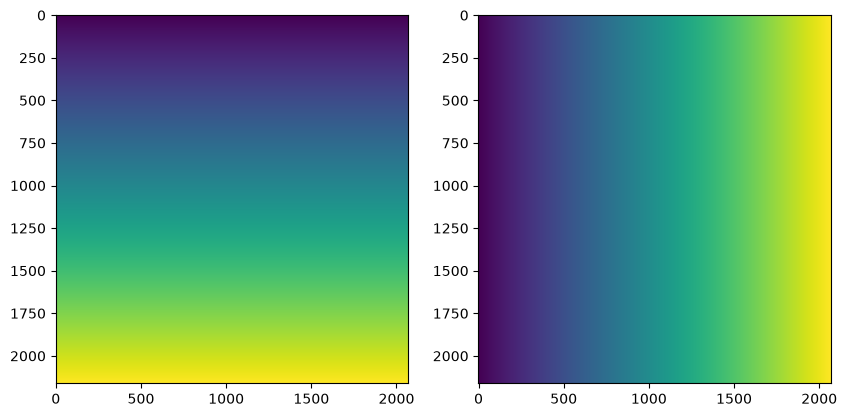

In [8]:
fig,ax = subplots(1, 2, figsize=(10,5))
d0,d1 = mm.calc_displacement_map()
ax[0].imshow(d0)
ax[1].imshow(d1);

In [9]:
# This is the theoritical q_value for the given ring (in nm^-1)
mm.init_q_theo()
print(mm._q_theo, mm.calibrants)

{} {}


## Calibration of the detector

Special care must be taken to obtain sub-pixel precision:
* Use a good calibrant providing thin rings ($\rm CeO_2$ 0.25µm)
* Use a monochromatic beam (55 keV)
* Use a small beam (200 µm)
* Use a fine capillary (500 µm) of non-absorbing material (kapton)
* Rotate the capillary
* Every single module of the detector should see at least one ring on each image
* Several beam-center position should be used, ideally one in the center of the detector and the four corners.
* Detector should be far enough from the sample so that parallax effects are negligible

Now: Load several geometries with their associated control points:

In [10]:
ponis = glob.glob("*.poni")
ponis.sort()
cpf = glob.glob("*.npt")
cpf.sort()
for i in zip(cpf, ponis):
    print(f"Loading Geometry: `{i[1]}` with control points: ", end="")
    mm.load_control_points(*i, verbose=True)    
print("Number of parameters to refine (modules + configurations): ", mm.nb_param)

Loading Geometry: `geometry_0001.poni` with control points: peaks_0001.npt : CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11
1 339
2 434
3 432
4 331
5 433
6 369
7 378
8 381
9 461
10 377
11 406
12 367
13 333
14 400
15 408
16 359
Loading Geometry: `geometry_0002.poni` with control points: peaks_0002.npt : CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11
1 340
2 356
3 331
4 429
5 381
6 371
7 395
8 371
9 357
10 376
11 401
12 362
13 327
14 354
15 347
16 428
Loading Geometry: `geometry_0003.poni` with control points: peaks_0003.npt : CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11
1 339
2 314
3 367
4 357
5 326
6 349
7 340
8 412
9 366
10 375
11 404
12 368
13 372
14 364
15 395
16 360
Loading Geometry: `geometry_0004.poni` with control points: peaks_0004.npt : CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11
1 356
2 352
3 363
4 364
5 318
6 421
7 413
8 342
9 441
10 377
11 396
12 369
13 438
14 361
15 388
16 379
Number of parameters to refine (modu

In [11]:
param = mm.init_param()
print("`param` is the concatenation of the displacement of the modules (45 values) and the 4 (geometries) x 5 poni-parameters") 
print(param)
print("Or in a better representation:")
mm.print_param(param)

`param` is the concatenation of the displacement of the modules (45 values) and the 4 (geometries) x 5 poni-parameters
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.42051487  0.08511216  0.07917643
 -0.00059227 -0.00127187  0.42059244  0.08538913  0.14840694 -0.00228102
 -0.00159133  0.42077269  0.12030359  0.14829317 -0.00222645 -0.0014802
  0.42071525  0.12003891  0.08080534 -0.00114215 -0.00114969]
Or in a better representation:
module # 1: d0   = 0.0, d1   = 0.0, rot  = 0.0,
module # 2: d0   = 0.0, d1   = 0.0, rot  = 0.0,
module # 3: d0   = 

In [12]:
param1 = param.copy()
param1[0] = 0.4 
mm.residu(param)==mm.residu(param1), param1==param

#%time mm.cost(param)

(array([ True,  True,  True, ...,  True, False, False], shape=(24020,)),
 array([False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True]))

In [13]:
mm.cost(param), mm.cost(param1)

(np.float64(5.2173986538511725), np.float64(5.2346098802336645))

In [14]:
cal = mm.calibrants['peaks_0001.npt']
cal.get_peaks(unit="q_nm^-1")[:10]

array([20.10993723, 23.22095533, 32.83938996, 38.50759804, 40.21987446,
       46.44191066, 50.60889865, 51.92363465, 56.87949214, 60.32981168])

In [15]:
mm.calibrants, mm._q_theo

({'peaks_0001.npt': CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11,
  'peaks_0002.npt': CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11,
  'peaks_0003.npt': CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11,
  'peaks_0004.npt': CeO2 Calibrant with 769 reflections at wavelength 2.2543e-11},
 {'peaks_0001.npt': array([20.10993723, 20.10993723, 20.10993723, ..., 73.43110856,
         73.43110856, 73.43110856], shape=(6208,)),
  'peaks_0002.npt': array([ 20.10993723,  20.10993723,  20.10993723, ..., 106.41178587,
         106.41178587, 106.41178587], shape=(5926,)),
  'peaks_0003.npt': array([ 20.10993723,  20.10993723,  20.10993723, ..., 116.10477666,
         116.10477666, 116.10477666], shape=(5808,)),
  'peaks_0004.npt': array([20.10993723, 20.10993723, 20.10993723, ..., 89.18177119,
         89.18177119, 89.18177119], shape=(6078,))})

In [16]:
mm.init_q_theo()

Here we refine the 45 parameters for the detector's module displacement and the 4 sets of PONI-parameters.

In [17]:
%time res = mm.refine(param, method="simplex")

CPU times: user 3h 25min 7s, sys: 5.89 s, total: 3h 25min 13s
Wall time: 3min 20s


In [18]:
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 4.838208601541527
             x: [-1.032e-04  6.188e-04 ... -1.148e-03 -1.145e-03]
           nit: 3218
          nfev: 3853
 final_simplex: (array([[-1.032e-04,  6.188e-04, ..., -1.148e-03,
                        -1.145e-03],
                       [-9.491e-05,  6.275e-04, ..., -1.148e-03,
                        -1.145e-03],
                       ...,
                       [-1.072e-04,  6.098e-04, ..., -1.148e-03,
                        -1.145e-03],
                       [-1.137e-04,  5.953e-04, ..., -1.148e-03,
                        -1.145e-03]], shape=(66, 65)), array([ 4.838e+00,  4.838e+00, ...,  4.838e+00,  4.838e+00],
                      shape=(66,)))

In [19]:
mm.print_param(res.x)

module # 1: d0   = -0.0001031548620744797, d1   = 0.0006188281013167502, rot  = 0.000531060160574163,
module # 2: d0   = 8.340677584631756e-05, d1   = -0.0005935527113772603, rot  = 0.0005400577693316256,
module # 3: d0   = -0.00016535828530762315, d1   = -0.00013388244708825145, rot  = -9.180477472699698e-07,
module # 4: d0   = -0.00026752323947075885, d1   = -8.003761028424987e-05, rot  = -0.00016574397959893885,
module # 5: d0   = 0.0001082423616866276, d1   = 0.00016841000507182195, rot  = -0.00011394627630168156,
module # 6: Fixed
module # 7: d0   = 0.0005213364496319624, d1   = -4.674528196587674e-06, rot  = -0.0011701001986836115,
module # 8: d0   = 0.00011543206590053049, d1   = 0.0003163785312592035, rot  = -0.0003800580545554909,
module # 9: d0   = -8.081167755197009e-05, d1   = -0.0007110135626295477, rot  = 0.00021134485211951606,
module #10: d0   = -0.00046938649684180047, d1   = -0.00030416141667965904, rot  = 0.0003071786486876602,
module #11: d0   = -5.3036660327654344e

In [20]:
print(f"Improvement of refined cost from {mm.cost(param)} --> {mm.cost(res.x)}")

Improvement of refined cost from 5.2173986538511725 --> 4.838208601541527


In [21]:
mm.ponis

{'peaks_0001.npt': {
     "poni_version": 2.1,
     "dist": 0.4205148684065302,
     "poni1": 0.08511216089571076,
     "poni2": 0.07917642888040256,
     "rot1": -0.0005922669937350214,
     "rot2": -0.0012718661240809642,
     "rot3": 0.0,
     "detector": "Eiger2CdTe_4M",
     "detector_config": {
         "pixel1": 7.5e-05,
         "pixel2": 7.5e-05,
         "orientation": 3,
         "sensor": {
             "material": "CdTe",
             "thickness": 0.00075
         }
     },
     "wavelength": 2.2543e-11
 },
 'peaks_0002.npt': {
     "poni_version": 2.1,
     "dist": 0.42059244257034567,
     "poni1": 0.08538913243703905,
     "poni2": 0.14840693889956444,
     "rot1": -0.0022810200806832374,
     "rot2": -0.001591329501402637,
     "rot3": 0.0,
     "detector": "Eiger2CdTe_4M",
     "detector_config": {
         "pixel1": 7.5e-05,
         "pixel2": 7.5e-05,
         "orientation": 3
     },
     "wavelength": 2.2543e-11
 },
 'peaks_0003.npt': {
     "poni_version": 2.1,
 

In [22]:
p1, p2 = mm.calc_cp_positions(key='peaks_0001.npt')
p1,p2

(array([0.0653617 , 0.0855331 , 0.11248565, ..., 0.0011495 , 0.00135361,
        0.00168997], shape=(6208,)),
 array([0.10301375, 0.04904512, 0.09138916, ..., 0.00204206, 0.00181054,
        0.00148118], shape=(6208,)))

In [23]:
ai = pyFAI.load("geometry_0001.poni")
mp1 = mm.modulated_points['peaks_0001.npt']
ai.qFunction(mp1.d0, mp1.d1)

array([20.12419836, 20.10782229, 20.0879135 , ..., 73.43321109,
       73.43830694, 73.42593236], shape=(6208,))

In [24]:
rp1, rp2, rp3 = ai.detector.calc_cartesian_positions(mp1.d0, mp1.d1,)
rp1, rp2, rp3

(array([0.0653617 , 0.0855331 , 0.11248565, ..., 0.0011495 , 0.00135361,
        0.00168997], shape=(6208,)),
 array([0.10301375, 0.04904512, 0.09138916, ..., 0.00204206, 0.00181054,
        0.00148118], shape=(6208,)),
 None)

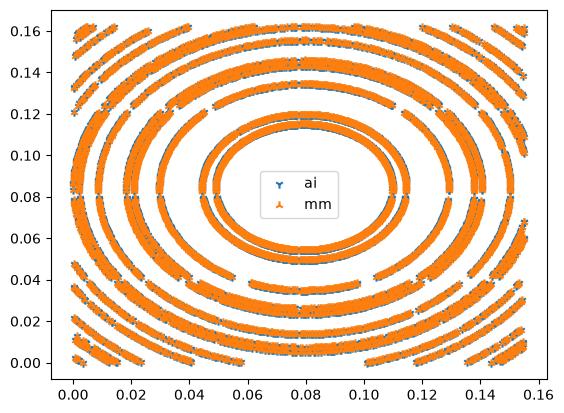

In [27]:
fig,ax = subplots()
ax.scatter(rp2, rp1, marker="1", label="ai")
ax.scatter(p2, p1, marker="2", label="mm")
ax.legend(loc="center");

## Saving the refined detector

`MultiModule.to_detector` applies the displacement of every module to the corners of the
pixels of the tabulated detector and returns a `Detector` object where the position of the
4 corners of each pixel is stored explicitly. This is the only way to describe a detector
which is neither uniform nor contiguous, and the NeXus format is the only one able to store
it. Such a file is read back with `pyFAI.detector_factory` and used like any other detector,
for example in a poni-file.

In [72]:
# Build a detector from the displaced modules:
refined_detector = mm.to_detector(res.x)

In [73]:
# Re-center pixels so that they are as close as possible from 
tabulated_detector = pyFAI.detector_factory("Eiger2_CdTe_4M")
pixel = tabulated_detector.pixel1
pixel_coord_tab = tabulated_detector.get_pixel_corners().astype(numpy.float64)
pixel_coord_pow = refined_detector.get_pixel_corners().astype(numpy.float64)
displ_refined = numpy.sqrt(((pixel_coord_pow - pixel_coord_tab)**2).sum(axis=-1))/pixel

kabsch = Kabsch(pixel_coord_tab.reshape((-1, 3)), pixel_coord_pow.reshape((-1, 3)))
pixel_coord_cen = kabsch.correct(pixel_coord_pow.reshape((-1, 3))).reshape(pixel_coord_tab.shape)
displ_aligned = numpy.sqrt(((pixel_coord_cen - pixel_coord_tab)**2).sum(axis=-1))/pixel

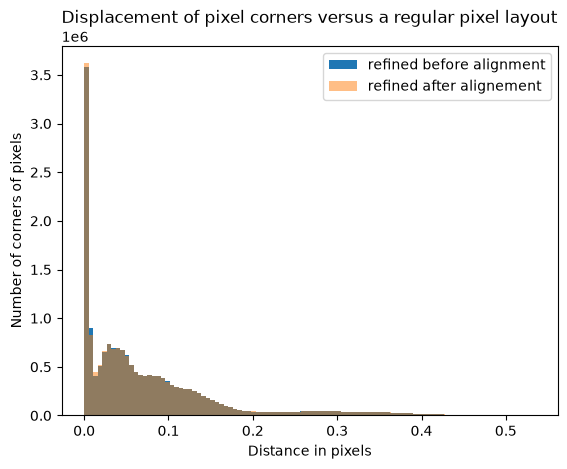

In [74]:
fig, ax = subplots()
ax.hist(displ_refined.ravel(), 100, label="refined before alignment", alpha=1)
ax.hist(displ_aligned.ravel(), 100, label="refined after alignement", alpha=0.5)
ax.set_title("Displacement of pixel corners versus a regular pixel layout")
ax.set_xlabel("Distance in pixels")
ax.set_ylabel("Number of corners of pixels")
ax.legend();

In [75]:
detector_file = "Eiger2CdTe_4M_ID11_powder.h5"
if os.path.exists(detector_file):
    os.remove(detector_file)
refined_detector.set_pixel_corners(pixel_coord_cen)
refined_detector.save(detector_file)
print(f"{detector_file}: {os.stat(detector_file).st_size/1e6:.1f} MB")
print(pyFAI.detector_factory(detector_file))

Eiger2CdTe_4M_ID11_powder.h5: 9.6 MB
Detector detector from NeXus file: Eiger2CdTe_4M_ID11_powder.h5	 PixelSize= 75µm, 75µm	 BottomRight (3)


## Validation of the method

Three descriptions of the very same detector are now compared:

* **Tabulated**: the nominal geometry of the `Eiger2 CdTe 4M` as distributed with pyFAI,
  where all modules are assumed to be perfectly aligned on a regular grid;
* **Grid of holes**: the geometry measured from the image of a grid-shaped mask, obtained
  in the [Eiger2-ID11](../Eiger_Calibration/Eiger2-ID11_grid.ipynb) tutorial for this very
  detector;
* **Powder rings**: the geometry refined in this notebook.

Each of them is used to calibrate the 4 images, independently from each other: the very
same control points are used, the refinement starts from the same poni-files, and both the
`wavelength` (known from the monochromator) and `rot3` are kept fixed. The residual error of
the calibration, i.e. the root mean square deviation between the measured position of the
rings and the expected one, then measures how well the detector is described: the better
the description, the smaller the residual.

In [76]:
def calibration_residuals(detector, fix=("wavelength", "rot3")):
    """Calibrate every image with a given detector and return the residual errors

    :param detector: the detector geometry to be validated
    :param fix: name of the parameters which are kept fixed during the refinement
    :return: list with the rms deviation to the expected ring position, in millidegree
    """
    residuals = []
    for npt, poni in zip(cpf, ponis):
        cp = ControlPoints(npt)
        sg = SingleGeometry(npt, control_points=cp, calibrant=cp.calibrant,
                            detector=detector, geometry=poni)
        gr = sg.geometry_refinement
        gr.refine3(fix=list(fix))
        residuals.append(1000 * numpy.rad2deg(numpy.sqrt(gr.chi2() / gr.data.shape[0])))
    return residuals


grid_file = "../Eiger_Calibration/Eiger2CdTe_4M_ID11_grid.h5"  # produced by the Eiger2-ID11 tutorial
validated = {"Tabulated": pyFAI.detector_factory("Eiger2_CdTe_4M")}
if os.path.exists(grid_file):
    validated["Grid of holes"] = pyFAI.detector_factory(grid_file)
else:
    print(f"{grid_file} is missing: run the Eiger2-ID11 tutorial to build it")
validated["Powder rings"] = pyFAI.detector_factory(detector_file)

%time residuals = {name: calibration_residuals(det) for name, det in validated.items()}

CPU times: user 8min 26s, sys: 3.76 s, total: 8min 29s
Wall time: 31.9 s


In [77]:
# Residual error of the calibration, image per image:

header = [os.path.splitext(i)[0] for i in cpf]
table = ["| Detector | " + " | ".join(header) + " | Mean |",
         "|:---|" + "---:|" * (len(header) + 1)]
for name, values in residuals.items():
    table.append(f"| {name} | " + " | ".join(f"{v:.3f}" for v in values) +
                 f" | **{numpy.mean(values):.3f}** |")
Markdown("Residual error of the calibration, in millidegree ($2\\theta$):\n\n" + "\n".join(table))

Residual error of the calibration, in millidegree ($2\theta$):

| Detector | peaks_0001 | peaks_0002 | peaks_0003 | peaks_0004 | Mean |
|:---|---:|---:|---:|---:|---:|
| Tabulated | 3.017 | 3.045 | 3.036 | 3.080 | **3.044** |
| Grid of holes | 2.707 | 2.760 | 2.803 | 2.790 | **2.765** |
| Powder rings | 2.946 | 2.900 | 2.912 | 2.964 | **2.930** |

The three descriptions are ranked as expected: any measured geometry beats the nominal one,
where the modules are assumed to be perfectly aligned. The gain is however modest, of the
order of a few percent on the residual, and the grid of holes still performs slightly better
than the powder rings on this dataset.

This is not what the original publication reports, and the reason is the amount of data
used here: the ~24000 control points of these 4 images are two orders of magnitude fewer
than the 223184 peak positions extracted in the paper, where a peak is fitted along every
single row and every single column of every module. With so few points, the 45 parameters
describing the module positions are only loosely constrained, which is also visible in the
modest decrease of the cost function during the refinement.

The three descriptions are ranked as expected: any measured geometry beats the nominal one,
where the modules are assumed to be perfectly aligned on a regular grid. The gain is however
modest, a few percent of the residual, and the grid of holes still performs slightly better
than the powder rings on this dataset. The reasons are discussed in the conclusion.

## Conclusion

The method described by Wright *et al.* is now available in pyFAI, in the
`pyFAI.detectors.multi_module` module: the position of the 16 modules of the Eiger2 CdTe 4M
(45 parameters, one module being fixed to remove the singularity of the problem) is refined
together with the geometry of the 4 powder patterns (4 × 5 parameters), i.e. 65 parameters
in total, from the ~24000 control points extracted from the images of a $\rm CeO_2$
capillary. The result is converted into a `Detector` object which holds the position of the
4 corners of every pixel and is saved as a NeXus file: it can then be used anywhere in
pyFAI, in a poni-file, for azimuthal integration or in `pyFAI-calib2`.

The validation performed above measures how well the detector is described by the residual
error left after calibrating each image: 3.04 m° with the tabulated detector, 2.93 m° with
the geometry refined here and 2.77 m° with the grid of holes. These values are to be
compared with the angle subtended by a single pixel, 10.2 m° at 42 cm: the calibration is
already accurate to about a third of a pixel, and describing the position of the modules
gains between 4% and 9% on this residual.

The precision claimed in the original publication, 1/350 pixel on the module positions, is
not reached here and several points deserve more work:

* **Number of control points.** The 24000 points used here are two orders of magnitude fewer
  than the 223184 peaks of the publication, where a peak is fitted along every single row
  and every single column of every module. Porting this extraction is probably the most
  efficient improvement to make.
* **Optimisation.** The refined translations stay below $10^{-3}$ pixel, i.e. essentially at
  their initial value, while the rotations reach $10^{-3}$ rad and carry all the correction:
  a rotation of $5\cdot10^{-4}$ rad already displaces the edge of a 512 pixel wide module by
  0.13 pixel. A Nelder-Mead simplex is not well suited to a 65-dimensional problem; the
  publication uses `curve_fit`, which exploits the derivatives of the residual and converges
  in less than a minute, where the simplex needs 3853 evaluations and does not seem to reach
  the global minimum.
* **Gauge of the model.** The publication constrains the mean of the shifts and of the rotations
  to be null while here we ensure to minimize the displacement between the corrected pixel position
  and the tabulated ones. Both remove the same singularity — a global
  translation and rotation of the detector, which is anyway absorbed by the poni-parameters
  — but the refined values cannot be compared directly with the published ones.
* **Data collection.** Only 4 beam-center positions were used. The recommendations listed at
  the beginning of this notebook, in particular having every module see several rings on
  each image, are the cheapest way to improve the conditioning of the problem.

In [ ]:
print(f"Total execution time: {time.perf_counter() - start_time:.3f}s")